In [1]:
import pandas as pd

df = pd.read_csv(r'C:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\local_folder\aggregated_company_data.csv')

### Zmienne wejściowe i target Score

In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

RESOLUTION = 1000
MIN_QUANTILE = 0.05
MAX_QUANTILE = 0.95

# =====================================================================
# 1. EARNINGS-TO-GROWTH
# =====================================================================
earnings_to_growth_min_val = df['Earnings-to-Growth'].quantile(MIN_QUANTILE)
earnings_to_growth_max_val = df['Earnings-to-Growth'].quantile(MAX_QUANTILE)
earnings_to_growth_step = (earnings_to_growth_max_val - earnings_to_growth_min_val) / RESOLUTION

earnings_to_growth_array = np.arange(earnings_to_growth_min_val, earnings_to_growth_max_val, earnings_to_growth_step)
earnings_to_growth_antecedent = ctrl.Antecedent(earnings_to_growth_array, 'Earnings-to-Growth')

# =====================================================================
# 2. ESG SIGNAL-TO-NOISE
# =====================================================================
esg_signal_to_noise_min_val = df['ESG_Signal-to-Noise'].quantile(MIN_QUANTILE)
esg_signal_to_noise_max_val = df['ESG_Signal-to-Noise'].quantile(MAX_QUANTILE)
esg_signal_to_noise_step = (esg_signal_to_noise_max_val - esg_signal_to_noise_min_val) / RESOLUTION

esg_signal_to_noise_array = np.arange(esg_signal_to_noise_min_val, esg_signal_to_noise_max_val, esg_signal_to_noise_step)
esg_signal_to_noise_antecedent = ctrl.Antecedent(esg_signal_to_noise_array, 'ESG_Signal-to-Noise')

# =====================================================================
# 3. PROFIT MARGIN MEAN
# =====================================================================
profit_margin_WMA_min_val = df['ProfitMargin_WMA'].quantile(MIN_QUANTILE)
profit_margin_WMA_max_val = df['ProfitMargin_WMA'].quantile(MAX_QUANTILE)
profit_margin_WMA_step = (profit_margin_WMA_max_val - profit_margin_WMA_min_val) / RESOLUTION

profit_margin_WMA_array = np.arange(profit_margin_WMA_min_val, profit_margin_WMA_max_val, profit_margin_WMA_step)
profit_margin_WMA_antecedent = ctrl.Antecedent(profit_margin_WMA_array, 'ProfitMargin_WMA')

# =====================================================================
# 4. PRICE-TO-SALES
# =====================================================================
price_to_sales_min_val = df['PriceToSales'].quantile(MIN_QUANTILE)
price_to_sales_max_val = df['PriceToSales'].quantile(MAX_QUANTILE)
price_to_sales_step = (price_to_sales_max_val - price_to_sales_min_val) / RESOLUTION

price_to_sales_array = np.arange(price_to_sales_min_val, price_to_sales_max_val, price_to_sales_step)
price_to_sales_antecedent = ctrl.Antecedent(price_to_sales_array, 'Price-to-Sales')

# =====================================================================
# TARGET SCORE (Wyjście / Consequent)
# =====================================================================
# Zostawiamy tak, jak napisałeś - tu chcemy mieć sztywny wynik np. od 0 do 100 punktów
TARGET_SCORE = ctrl.Consequent(np.arange(0, 101, 0.1), 'TARGET_SCORE')

### Membership functions

#### 0) Ranges

In [3]:
LOW_QUANTILE = 0.25
MID_QUANTILE = 0.5
HIGH_QUANTILE = 0.75

#### 1) Earnings-to-growth

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


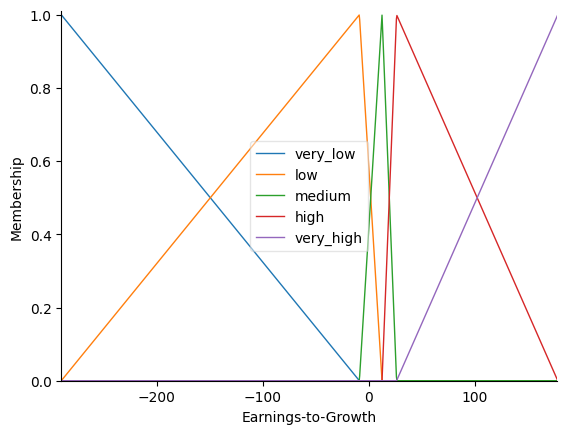

In [ ]:
q_min = earnings_to_growth_min_val
q_low = df['Earnings-to-Growth'].quantile(LOW_QUANTILE)
q_mid = df['Earnings-to-Growth'].quantile(MID_QUANTILE)
q_high = df['Earnings-to-Growth'].quantile(HIGH_QUANTILE)
q_max = earnings_to_growth_max_val 

universe_etg = earnings_to_growth_antecedent.universe

# 1. VERY LOW: Szczyt na samym lewym skraju, opada do q_low
earnings_to_growth_antecedent['very_low'] = fuzz.trimf(universe_etg, [q_min, q_min, q_low])

# 2. LOW: Zaczyna się na dnie (q_min), szczytuje na q_low, kończy na środku (q_mid)
earnings_to_growth_antecedent['low'] = fuzz.trimf(universe_etg, [q_min, q_low, q_mid])

# 3. MEDIUM: Typowy środek rynku - symetryczny trójkąt wokół mediany (q_mid)
earnings_to_growth_antecedent['medium'] = fuzz.trimf(universe_etg, [q_low, q_mid, q_high])

# 4. HIGH: Zaczyna się od środka (q_mid), szczytuje na q_high, kończy na maksimum (q_max)
earnings_to_growth_antecedent['high'] = fuzz.trimf(universe_etg, [q_mid, q_high, q_max])

# 5. VERY HIGH: Zaczyna się na q_high, rośnie do maksimum i tam zostaje (q_max)
earnings_to_growth_antecedent['high'] = fuzz.trimf(universe_etg, [q_high, q_max, q_max])

earnings_to_growth_antecedent.view()

#### 2) ESG Signal-to-Noise

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


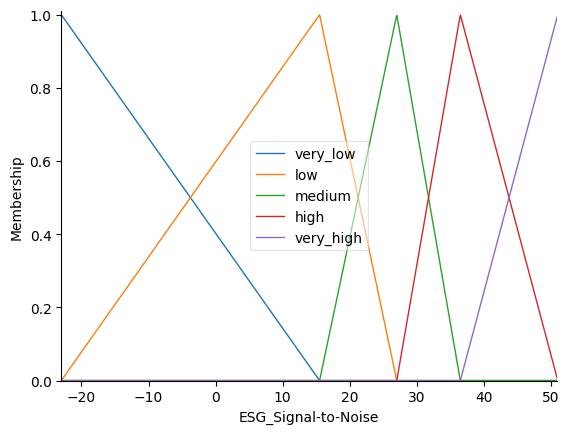

In [5]:

q_min = esg_signal_to_noise_min_val
q_low = df['ESG_Signal-to-Noise'].quantile(LOW_QUANTILE)
q_mid = df['ESG_Signal-to-Noise'].quantile(MID_QUANTILE)
q_high = df['ESG_Signal-to-Noise'].quantile(HIGH_QUANTILE)
q_max = esg_signal_to_noise_max_val

universe_esg = esg_signal_to_noise_antecedent.universe

esg_signal_to_noise_antecedent['very_low'] = fuzz.trimf(universe_esg, [q_min, q_min, q_low])
esg_signal_to_noise_antecedent['low'] = fuzz.trimf(universe_esg, [q_min, q_low, q_mid])
esg_signal_to_noise_antecedent['medium'] = fuzz.trimf(universe_esg, [q_low, q_mid, q_high])
esg_signal_to_noise_antecedent['high'] = fuzz.trimf(universe_esg, [q_mid, q_high, q_max])
esg_signal_to_noise_antecedent['very_high'] = fuzz.trimf(universe_esg, [q_high, q_max, q_max])

esg_signal_to_noise_antecedent.view()

#### 3) Profit Margin WMA

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


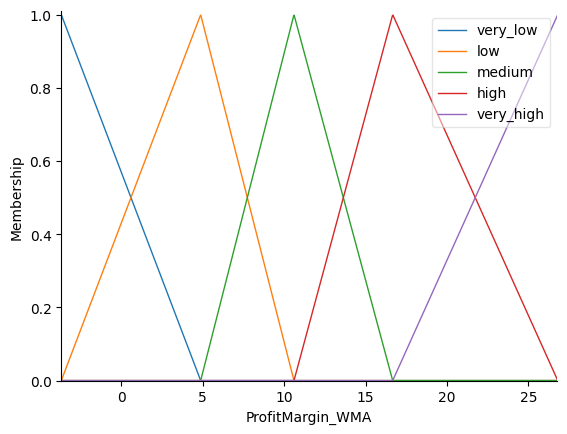

In [6]:
q_min = profit_margin_WMA_min_val
q_low = df['ProfitMargin_WMA'].quantile(LOW_QUANTILE)
q_mid = df['ProfitMargin_WMA'].quantile(MID_QUANTILE)
q_high = df['ProfitMargin_WMA'].quantile(HIGH_QUANTILE)
q_max = profit_margin_WMA_max_val

universe_profit = profit_margin_WMA_antecedent.universe

profit_margin_WMA_antecedent['very_low'] = fuzz.trimf(universe_profit, [q_min, q_min, q_low])
profit_margin_WMA_antecedent['low'] = fuzz.trimf(universe_profit, [q_min, q_low, q_mid])
profit_margin_WMA_antecedent['medium'] = fuzz.trimf(universe_profit, [q_low, q_mid, q_high])
profit_margin_WMA_antecedent['high'] = fuzz.trimf(universe_profit, [q_mid, q_high, q_max])
profit_margin_WMA_antecedent['very_high'] = fuzz.trimf(universe_profit, [q_high, q_max, q_max])

profit_margin_WMA_antecedent.view()

#### 4) Price-to-sales

c:\Users\majch\OneDrive\Dokumenty\Wojtek\STUDIA\SEMESTR_4\MSID\laby\MSiD_Project\.venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


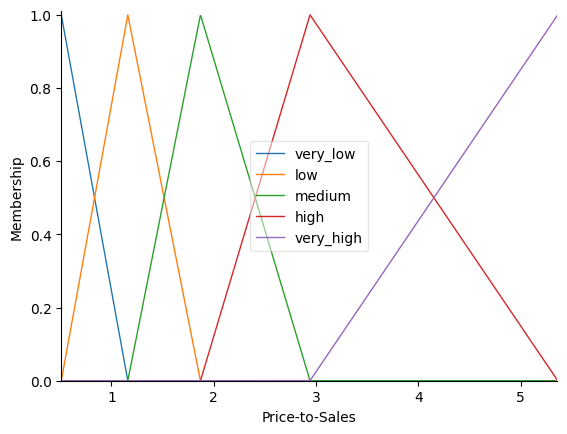

In [8]:
q_min = price_to_sales_min_val
q_low = df['PriceToSales'].quantile(LOW_QUANTILE)
q_mid = df['PriceToSales'].quantile(MID_QUANTILE)
q_high = df['PriceToSales'].quantile(HIGH_QUANTILE)
q_max = price_to_sales_max_val

universe_pts = price_to_sales_antecedent.universe

price_to_sales_antecedent['very_low'] = fuzz.trimf(universe_pts, [q_min, q_min, q_low])
price_to_sales_antecedent['low'] = fuzz.trimf(universe_pts, [q_min, q_low, q_mid])
price_to_sales_antecedent['medium'] = fuzz.trimf(universe_pts, [q_low, q_mid, q_high])
price_to_sales_antecedent['high'] = fuzz.trimf(universe_pts, [q_mid, q_high, q_max])
price_to_sales_antecedent['very_high'] = fuzz.trimf(universe_pts, [q_high, q_max, q_max])

price_to_sales_antecedent.view()

#### 5) Target Score

In [ ]:
universe_target = TARGET_SCORE.universe

# Parametr sigma określa "szerokość" dzwonu Gaussa.
# Przy środkach oddalonych od siebie o 20, sigma=10 daje idealny overlap (nachodzenie na siebie)
sigma_val = 10

TARGET_SCORE['very_bad'] = fuzz.gaussmf(universe_target, 10, sigma_val)
TARGET_SCORE['bad'] = fuzz.gaussmf(universe_target, 30, sigma_val)
TARGET_SCORE['medium'] = fuzz.gaussmf(universe_target, 50, sigma_val)
TARGET_SCORE['good'] = fuzz.gaussmf(universe_target, 70, sigma_val)
TARGET_SCORE['very_good'] = fuzz.gaussmf(universe_target, 90, sigma_val)

# TARGET_SCORE.view()

### Fuzzy Rules
#### Wpływ metryki na TARGET_SCORE :
- Earnings-to-growth: 3
- ESG_signal-to-noise: 2
- PriceToSales: 2
- ProfitMargin_WMA: 1

- very_low = 0
- low = 1
- medium = 2
- high = 3
- very_high = 4

WIĘC MAX_TARGET_SCORE = 3*4 + 2*4 + 2*4 + 4 = 32. ZATEM:

- very_low: 0 - 6 pkt
- low: 7 - 13 pkt
- medium: 14 - 19 pkt
- high: 20 - 25 pkt
- very_high: 26 - 32 pkt

NA TEJ PODSTAWIE TWORZĘ REGUŁY 


In [ ]:
etg = earnings_to_growth_antecedent
esg = esg_signal_to_noise_antecedent
pts = price_to_sales_antecedent
pmw = profit_margin_WMA_antecedent # to jest moderator - uwzględniamy, gdy mamy stykowe sytuacje


rules = [
    # Przypadki, kiedy na pewno będzie very high lub takie, że dwie metryki są very_high, ale coś je ciągnie w dół

    ctrl.Rule(etg['very_high'] & esg['very_high'] & ( pts['very_high'] | pts['high'] ), TARGET_SCORE['very_high']),
    ctrl.Rule(etg['very_high'] & esg['very_high'] & ( pts['medium'] | pts['low']) & ( pmw['very_high'] | pmw['high']), TARGET_SCORE['high']),
    ctrl.Rule(etg['very_high'] & esg['very_high'] &  pts['very_low'], TARGET_SCORE['medium']),

    ctrl.Rule(etg['very_high'] & pts['very_high'] & ( esg['very_high'] | esg['high'] ), TARGET_SCORE['very_high']),
    ctrl.Rule(etg['very_high'] & pts['very_high'] & ( esg['medium'] | esg['low'] ) & ( pmw['very_high'] | pmw['high']), TARGET_SCORE['high']),
    ctrl.Rule(etg['very_high'] & pts['very_high'] & esg['very_low'], TARGET_SCORE['medium']),

    ctrl.Rule(etg['very_high'] & esg['high'] & pts['high'], TARGET_SCORE['very_high']),
    ctrl.Rule(etg['high'] & esg['very_high'] & pts['very_high'], TARGET_SCORE['very_high']),

    ctrl.Rule(etg['high'] & ((esg['very_high'] & pts['high']) | (esg['high'] & pts['very_high'])) & (pmw['very_high'] | pmw['high']), TARGET_SCORE['very_high']),
    ctrl.Rule(etg['high'] & ((esg['very_high'] & pts['high']) | (esg['high'] & pts['very_high'])) & (pmw['medium'] | pmw['low'] | pmw['very_low']), TARGET_SCORE['high']),

    # Przypadki high lub dwie są high, jedna niżej i pmw może zadecydować

    ctrl.Rule( etg['high'] & esg['high'] & ( pts['very_high'] | pts['high']), TARGET_SCORE['high']),
    ctrl.Rule( etg['high'] & esg['high'] & ( pts['medium'] | pts['low'] ) & ( pmw['very_high'] | pmw['high'] | pmw['medium']), TARGET_SCORE['high']),
    ctrl.Rule( etg['high'] & esg['high'] & ( pts['medium'] | pts['low'] | pts['very_low'] ) & ( pmw['low'] | pmw['very_low'] ), TARGET_SCORE['medium']),
    ctrl.Rule( etg['high'] & esg['high'] & ( pts['very_low'] ), TARGET_SCORE['medium']),

    ctrl.Rule( etg['high'] & ( esg['very_high'] | esg['high'] ) & pts['high'], TARGET_SCORE['high']),
    ctrl.Rule( etg['high'] & ( esg['medium'] | esg['low'] ) & pts['high'] & ( pmw['very_high'] | pmw['high'] | pmw['medium'] ), TARGET_SCORE['high']),
    ctrl.Rule( etg['high'] & ( esg['medium'] | esg['low'] ) & pts['high'] & ( pmw['low'] | pmw['very_low']), TARGET_SCORE['medium']),
    ctrl.Rule( etg['high'] & esg['very_low'] & pts['high'], TARGET_SCORE['medium']),

    ctrl.Rule( etg['high'] & esg['medium'] & pts['medium'] & ( pmw['very_high'] | pmw['high'] | pmw['medium']), TARGET_SCORE['high']),
    ctrl.Rule( etg['high'] & esg['medium'] & pts['medium'] & ( pmw['low'] | pmw['very_low']), TARGET_SCORE['medium']),

    # Przypadki na medium lub gdy medium zostanie ściągnięte na low / high
    # Ale metryki nie są rozstrzelone
    ctrl.Rule( etg['medium'] & esg['medium'] & ( pts['low'] | pts['medium'] | pts['high']), TARGET_SCORE['medium']),

    ctrl.Rule( etg['medium'] & esg['medium'] & ( pts['very_high']) & ( pmw['high'] |  pmw['very_high']), TARGET_SCORE['high']),
    ctrl.Rule( etg['medium'] & esg['medium'] & pts['very_high'] & pmw['medium'], TARGET_SCORE['medium']),

    ctrl.Rule( etg['medium'] & esg['medium'] & ( pts['very_low']) & ( pmw['very_low'] | pmw['low']), TARGET_SCORE['low']),
    ctrl.Rule( etg['medium'] & esg['medium'] & pts['very_low'] & pmw['medium'], TARGET_SCORE['medium']),

    # -------

    ctrl.Rule( etg['medium'] & pts['medium'] & ( esg['low'] | esg['medium'] | esg['high']), TARGET_SCORE['medium']),

    ctrl.Rule( etg['medium'] & pts['medium'] & ( esg['very_high']) & ( pmw['high'] |  pmw['very_high']), TARGET_SCORE['high']),
    ctrl.Rule( etg['medium'] & pts['medium'] & esg['very_high'] & pmw['medium'], TARGET_SCORE['medium']),

    ctrl.Rule( etg['medium'] & pts['medium'] & ( esg['very_low']) & ( pmw['very_low'] | pmw['low']), TARGET_SCORE['low']),
    ctrl.Rule( etg['medium'] & pts['medium'] & esg['very_low'] & pmw['medium'], TARGET_SCORE['medium']),

    # Przypadki na medium lub gdy medium zostanie ściągnięte na low / high
    # Ale metryki SĄ rozstrzelone

    ctrl.Rule( etg['very_low'] & (esg['high'] | esg['very_high']) & (pts['high'] | pts['very_high']), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_low'] & esg['medium'] & pts['medium'] & ( pmw['high'] | pmw['very_high'] | pmw['medium']), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_low'] & esg['medium'] & pts['medium'] & ( pmw['low'] | pmw['very_low'] | pmw['medium']), TARGET_SCORE['low'] ),

    ctrl.Rule( etg['very_low'] & (esg['high'] | esg['very_high']) & (pts['low'] | pts['very_low']) & ( pmw['high'] | pmw['very_high'] ), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_low'] & (esg['high'] | esg['very_high']) & (pts['low'] | pts['very_low']) & ( pmw['very_low'] | pmw['low'] | pmw['medium']), TARGET_SCORE['low'] ),

    ctrl.Rule( etg['very_high'] & (esg['low'] | esg['very_low']) & (pts['low'] | pts['very_low']), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_high'] & esg['medium'] & pts['medium'] & ( pmw['low'] | pmw['very_low'] | pmw['medium']), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_high'] & esg['medium'] & pts['medium'] & ( pmw['high'] | pmw['very_high'] | pmw['medium']), TARGET_SCORE['high'] ),

    ctrl.Rule( etg['very_low'] & (pts['high'] | pts['very_high']) & (esg['low'] | esg['very_low']) & ( pmw['high'] | pmw['very_high'] ), TARGET_SCORE['medium'] ),
    ctrl.Rule( etg['very_low'] & (pts['high'] | pts['very_high']) & (esg['low'] | esg['very_low']) & ( pmw['very_low'] | pmw['low'] | pmw['medium']), TARGET_SCORE['low'] ),

    # Przypadki low lub dwie są low, jedna wyżej i pmw może zadecydować
    ctrl.Rule( etg['low'] & esg['low'] & ( pts['very_low'] | pts['low']), TARGET_SCORE['low']),
    ctrl.Rule( etg['low'] & esg['low'] & ( pts['medium'] | pts['high'] ) & ( pmw['very_low'] | pmw['low'] | pmw['medium']), TARGET_SCORE['low']),
    ctrl.Rule( etg['low'] & esg['low'] & ( pts['medium'] | pts['high'] | pts['very_high'] ) & ( pmw['high'] | pmw['very_high'] ), TARGET_SCORE['medium']),
    ctrl.Rule( etg['low'] & esg['low'] & ( pts['very_high'] ), TARGET_SCORE['medium']),

    ctrl.Rule( etg['low'] & ( esg['very_low'] | esg['low'] ) & pts['low'], TARGET_SCORE['low']),
    ctrl.Rule( etg['low'] & ( esg['medium'] |  esg ['high'] ) & pts['low'] & ( pmw['very_low'] | pmw['low'] | pmw['medium'] ), TARGET_SCORE['low']),
    ctrl.Rule( etg['low'] & ( esg['medium'] |  esg ['high'] ) & pts['low'] & ( pmw['high'] | pmw['very_high']), TARGET_SCORE['medium']),
    ctrl.Rule( etg['low'] & esg['very_high'] & pts['low'], TARGET_SCORE['medium']),

    ctrl.Rule( etg['low'] & esg['medium'] & pts['medium'] & ( pmw['very_low'] | pmw['low'] | pmw['medium']), TARGET_SCORE['low']),
    ctrl.Rule( etg['low'] & esg['medium'] & pts['medium'] & ( pmw['high'] | pmw['very_high']), TARGET_SCORE['medium']),

    # Przypadki, kiedy na pewno będzie very low lub takie, że dwie metryki są very_low, ale coś je ciągnie w górę
    ctrl.Rule(etg['very_low'] & esg['very_low'] & ( pts['very_low'] | pts['low'] ), TARGET_SCORE['very_low']),
    ctrl.Rule(etg['very_low'] & esg['very_low'] & ( pts['medium'] | pts['high'] | pts['very_high']) & ( pmw['very_low'] | pmw['low']), TARGET_SCORE['low']),
    ctrl.Rule(etg['very_low'] & esg['very_low'] & pts['very_high'], TARGET_SCORE['medium']),

    ctrl.Rule(etg['very_low'] & pts['very_low'] & ( esg['very_low'] | esg['low'] ), TARGET_SCORE['very_low']),
    ctrl.Rule(etg['very_low'] & pts['very_low'] & ( esg['medium'] | esg['high'] ) & ( pmw['very_low'] | pmw['low']), TARGET_SCORE['low']),
    ctrl.Rule(etg['very_low'] & pts['very_low'] & esg['very_high'], TARGET_SCORE['medium']),

    ctrl.Rule(etg['very_low'] & esg['low'] & pts['low'], TARGET_SCORE['very_low']),
    ctrl.Rule(etg['low'] & esg['very_low'] & pts['very_low'], TARGET_SCORE['very_low']),

    ctrl.Rule(etg['low'] & ((esg['very_low'] & pts['low']) | (esg['low'] & pts['very_low'])) & (pmw['very_low'] | pmw['low']), TARGET_SCORE['very_low']),
    ctrl.Rule(etg['low'] & ((esg['very_low'] & pts['low']) | (esg['low'] & pts['very_low'])) & (pmw['medium'] | pmw['high'] | pmw['very_high']), TARGET_SCORE['low']),
]